<a href="https://colab.research.google.com/github/rahulatrkm/ObjectRecognizer/blob/main/original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS541 Challenge — Student Starter Baseline


This notebook provides a simple baseline students can extend.

What this starter includes:
- CIFAR-100 train/val/test pipeline
- A basic CNN baseline model
- Training + validation loop
- OOD inference and submission file generation

What students should improve:
- Better model architectures
- Better optimization schedules
- Better regularization and augmentation
- Better OOD robustness


In [1]:
# Runtime configuration
FAST_DEV_RUN = False  # True = quick smoke test
SEED = 42

import os

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK_ROOT = "/content" if IN_COLAB else os.path.abspath("./temp_student")
os.makedirs(WORK_ROOT, exist_ok=True)

DATA_ROOT = os.path.join(WORK_ROOT, "data")
OOD_DIR = os.path.join(WORK_ROOT, "ood-test-CS541")
SUBMISSION_PATH = os.path.join(WORK_ROOT, "submission_ood.csv")

print("IN_COLAB:", IN_COLAB)
print("WORK_ROOT:", WORK_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OOD_DIR:", OOD_DIR)
print("SUBMISSION_PATH:", SUBMISSION_PATH)


IN_COLAB: True
WORK_ROOT: /content
DATA_ROOT: /content/data
OOD_DIR: /content/ood-test-CS541
SUBMISSION_PATH: /content/submission_ood.csv


In [2]:
# Install required packages (safe to re-run)
import importlib.util
import subprocess
import sys

required = ["torch", "torchvision", "tqdm", "numpy", "pandas", "matplotlib", "huggingface_hub"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])

print("Environment ready")


Environment ready


In [3]:
import os
import random
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def accuracy_top1(logits: torch.Tensor, targets: torch.Tensor) -> float:
    return (logits.argmax(dim=1) == targets).float().mean().item()


def make_loaders(batch_size: int, num_workers: int) -> Tuple[DataLoader, DataLoader, DataLoader]:
    mean = (0.5071, 0.4867, 0.4408) ### DO NOT CHANGE THIS
    std = (0.2675, 0.2565, 0.2761) ### DO NOT CHANGE THIS
    train_tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
    eval_tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    n = len(train_full)
    n_train = int(0.8 * n)
    n_val = n - n_train
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_train, n_val], generator=g)

    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(2048, len(train_ds))))
        val_ds = torch.utils.data.Subset(val_ds, range(min(1024, len(val_ds))))
        test_ds = torch.utils.data.Subset(test_ds, range(min(1024, len(test_ds))))

    if IN_COLAB:
        num_workers = 0

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    return train_loader, val_loader, test_loader


class SimpleCNN(nn.Module):
    """A lightweight baseline CNN for CIFAR-100."""
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
) -> Dict[str, list]:
    history = {"train_acc": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        tr_correct, tr_total = 0, 0
        for x, y in tqdm(train_loader, desc=f"train {epoch}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            tr_correct += (logits.argmax(1) == y).sum().item()
            tr_total += y.numel()

        model.eval()
        va_correct, va_total = 0, 0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"val {epoch}/{epochs}", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                va_correct += (logits.argmax(1) == y).sum().item()
                va_total += y.numel()

        tr_acc = tr_correct / max(tr_total, 1)
        va_acc = va_correct / max(va_total, 1)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:03d}/{epochs} | train {tr_acc:.4f} | val {va_acc:.4f}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    print("Best val acc:", best_val_acc)
    return history


@torch.no_grad()
def eval_clean(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total


set_seed(SEED)
device = get_device()
print("Device:", device)


Device: cuda


In [4]:
# Baseline training config
CFG = {
    "batch_size": 128,
    "num_workers": 0 if IN_COLAB else 2,
    "epochs": 10 if not FAST_DEV_RUN else 2,
    "lr": 1e-3,
    "weight_decay": 1e-4,
}

train_loader, val_loader, test_loader = make_loaders(CFG["batch_size"], CFG["num_workers"])

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

history = fit(model, train_loader, val_loader, optimizer, criterion, device, CFG["epochs"])
test_acc = eval_clean(model, test_loader, device)
print(f"Clean CIFAR-100 test accuracy: {test_acc:.2f}%")


100%|██████████| 169M/169M [00:02<00:00, 79.0MB/s]


train 1/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/10 | train 0.1115 | val 0.2135


train 2/10:   0%|          | 0/313 [00:00<?, ?it/s]

...

val 9/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 009/10 | train 0.5800 | val 0.4278


train 10/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 010/10 | train 0.6169 | val 0.4345
Best val acc: 0.4345
Clean CIFAR-100 test accuracy: 43.95%


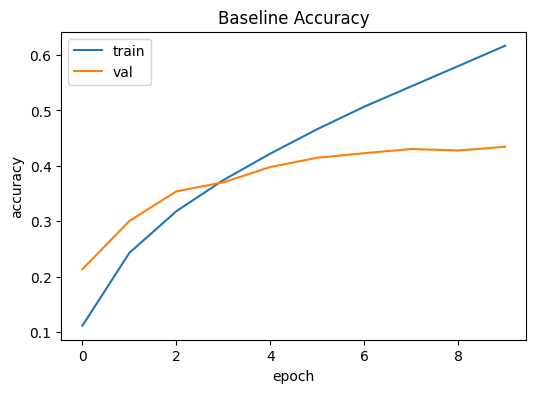

In [5]:
# Optional quick plot of train/val accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Baseline Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()


## OOD Submission Generation

This section creates `submission_ood.csv` for challenge evaluation.

Submission format:
- `id`: `distortionXX_severity_index`
- `label`: predicted class in `[0, 99]`


In [6]:
### DO NOT CHANGE THE BELOW, REPLACE WITH YOUR MODEL, THE SUBMISSION FILES NEED TO GO THROUGH THE BELOW PREPROCESSING

from huggingface_hub import snapshot_download

def ensure_ood_files(ood_dir: str) -> None:
    os.makedirs(ood_dir, exist_ok=True)
    print("Downloading OOD files from Hugging Face dataset...")
    snapshot_download(
        repo_id="XThomasBU/ood-test-CS541",
        repo_type="dataset",
        local_dir=ood_dir,
        local_dir_use_symlinks=False,
    )
    print("OOD files ready in", ood_dir)


@torch.no_grad()
def predict_file(model: nn.Module, npy_path: str, severity: int, batch_size: int) -> np.ndarray:
    images = np.load(npy_path, mmap_mode="r")
    start = (severity - 1) * 10000
    end = severity * 10000

    mean = (0.5071, 0.4867, 0.4408)
    std = (0.2675, 0.2565, 0.2761)
    normalize = transforms.Normalize(mean, std)

    preds = []
    model.eval()
    for b0 in tqdm(range(start, end, batch_size), desc=f"{os.path.basename(npy_path)} sev{severity}", leave=False):
        b1 = min(b0 + batch_size, end)
        xb_np = np.array(images[b0:b1], copy=True)
        xb = torch.from_numpy(xb_np).permute(0, 3, 1, 2).float().div(255.0)
        xb = normalize(xb).to(device, non_blocking=True)
        logits = model(xb)
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds, axis=0)


ensure_ood_files(OOD_DIR)

distortion_files = sorted([p for p in os.listdir(OOD_DIR) if p.startswith("distortion") and p.endswith(".npy")])
print("Distortion files found:", len(distortion_files))

rows = []
BATCH = 64 if device.type == "cuda" else 32
for fname in distortion_files:
    dname = os.path.splitext(fname)[0]
    path = os.path.join(OOD_DIR, fname)
    for severity in [1, 2, 3, 4, 5]:
        pred = predict_file(model, path, severity, BATCH)
        for i, y in enumerate(pred.tolist()):
            rows.append((f"{dname}_{severity}_{i}", int(y)))
        print(f"{dname}_{severity} done")

submission = pd.DataFrame(rows, columns=["id", "label"])
submission.to_csv(SUBMISSION_PATH, index=False)
print("Wrote", SUBMISSION_PATH, "rows:", len(submission))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

OOD files ready in /content/ood-test-CS541
Distortion files found: 20


distortion00.npy sev1:   0%|          | 0/157 [00:00<?, ?it/s]

distortion00_1 done


...

distortion_19_3 done


distortion_19.npy sev4:   0%|          | 0/157 [00:00<?, ?it/s]

distortion_19_4 done


distortion_19.npy sev5:   0%|          | 0/157 [00:00<?, ?it/s]

distortion_19_5 done
Wrote /content/submission_ood.csv rows: 1000000


## Student Next Steps

- Replace `SimpleCNN` with stronger models.
- Add regularization and more robust training techniques.
- Keep submission format exactly as required (`id,label`).
